In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../")

from src.pipeline.data_loader import load_data, get_data_summary
from src.config import TARGET_COLUMN

%matplotlib inline
sns.set_theme(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = load_data()
get_data_summary(df)
df.head()

✅ Loading data from: c:\Users\HP\churn_prediction_system\data\raw\customers.csv

📊 DATA SUMMARY
Total Customers   : 1000
Total Features    : 16
Churned Customers : 598 (59.8%)
Missing Values    : 0
Duplicate Rows    : 0



,customer_id,age,gender,tenure_months,contract_type,payment_method,internet_service,monthly_charges,num_products,num_support_tickets,login_frequency,avg_session_duration,days_since_last_login,total_charges,clv,churn
0,CUST_0001,56,Male,40,Two Year,Electronic Check,DSL,82.70,2,0,18,3.26,34,3967.51,6553.98,0
1,CUST_0002,69,Male,45,One Year,Bank Transfer,Fiber Optic,100.84,5,4,25,37.67,133,4995.94,8653.66,0
2,CUST_0003,46,Male,62,One Year,Bank Transfer,Fiber Optic,81.16,2,9,25,46.89,18,5764.37,13783.38,0
3,CUST_0004,32,Female,58,Month-to-Month,Electronic Check,No,49.57,5,4,29,30.52,7,3048.94,5431.65,0
4,CUST_0005,60,Male,67,Two Year,Electronic Check,DSL,45.57,5,4,0,22.09,9,3488.31,6039.65,0


In [3]:
print("📋 Column Info:")
print(df.dtypes)
print(f"\n📊 Shape: {df.shape}")

📋 Column Info:
customer_id               object
age                        int64
gender                    object
tenure_months              int64
contract_type             object
payment_method            object
internet_service          object
monthly_charges          float64
num_products               int64
num_support_tickets        int64
login_frequency            int64
avg_session_duration     float64
days_since_last_login      int64
total_charges            float64
clv                      float64
churn                      int64
dtype: object

📊 Shape: (1000, 16)


C:\Users\HP\AppData\Local\Temp\ipykernel_14904\3678278623.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="churn", palette="Set2", ax=axes[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_14904\3678278623.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Stayed", "Churned"])


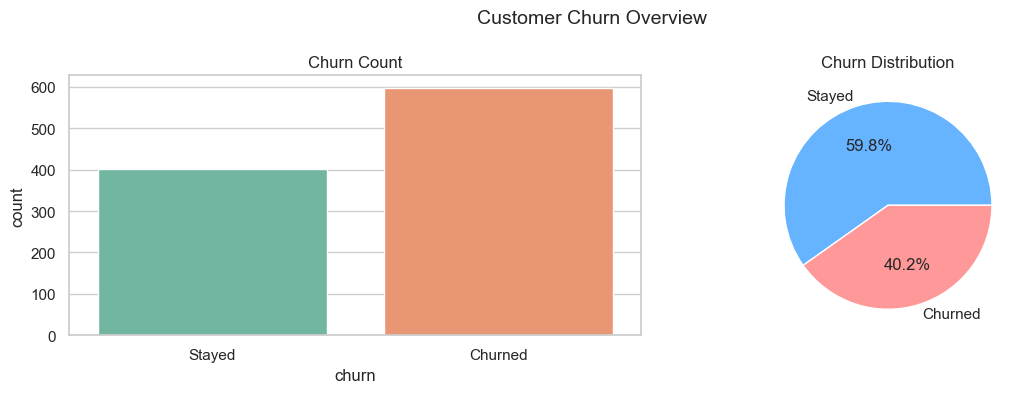

Churn Rate: 59.8%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x="churn", palette="Set2", ax=axes[0])
axes[0].set_title("Churn Count")
axes[0].set_xticklabels(["Stayed", "Churned"])

# Pie chart
churn_counts = df["churn"].value_counts()
axes[1].pie(
    churn_counts,
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%",
    colors=["#66b3ff","#ff9999"]
)
axes[1].set_title("Churn Distribution")

plt.suptitle("Customer Churn Overview", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Churn Rate: {df['churn'].mean()*100:.1f}%")

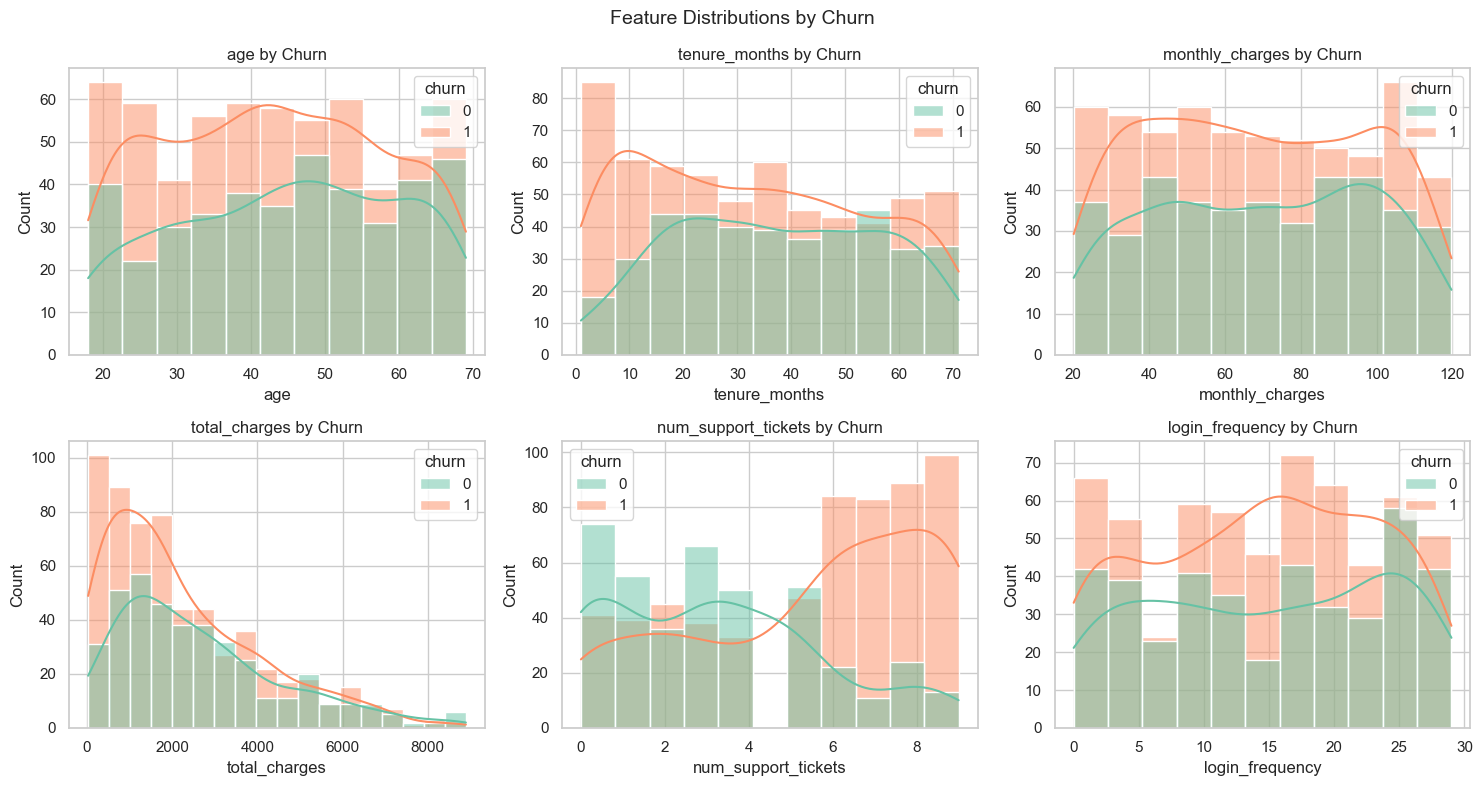

In [5]:
num_cols = [
    "age", "tenure_months", "monthly_charges",
    "total_charges", "num_support_tickets", "login_frequency"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, x=col, hue="churn",
        kde=True, palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"{col} by Churn")

plt.suptitle("Feature Distributions by Churn", fontsize=14)
plt.tight_layout()
plt.show()

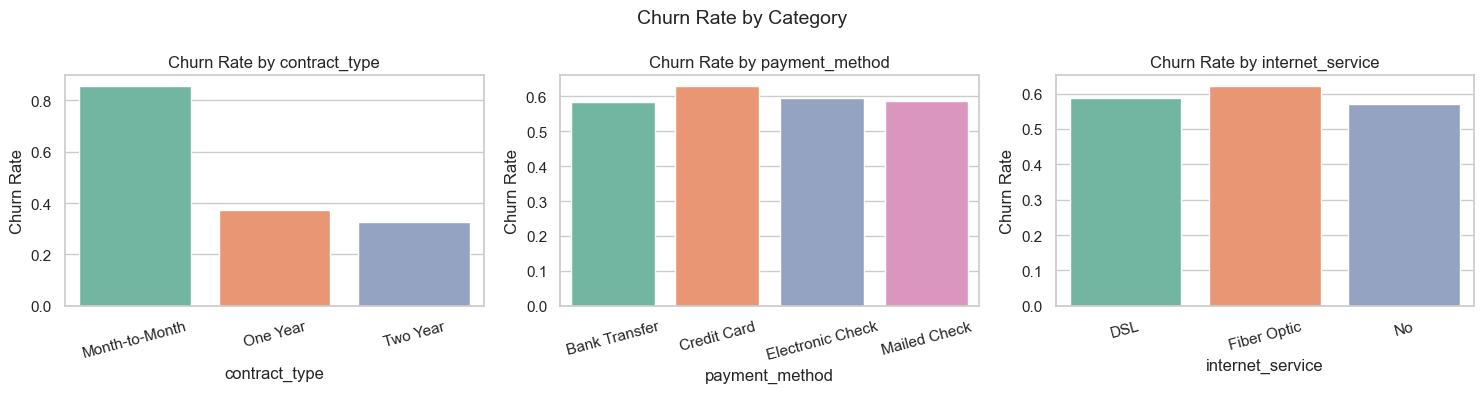

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_cols = ["contract_type", "payment_method", "internet_service"]

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["churn"].mean().reset_index()
    sns.barplot(
        data=churn_rate,
        x=col, y="churn",
        hue=col,
        legend=False,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Churn Rate by Category", fontsize=14)
plt.tight_layout()
plt.show()

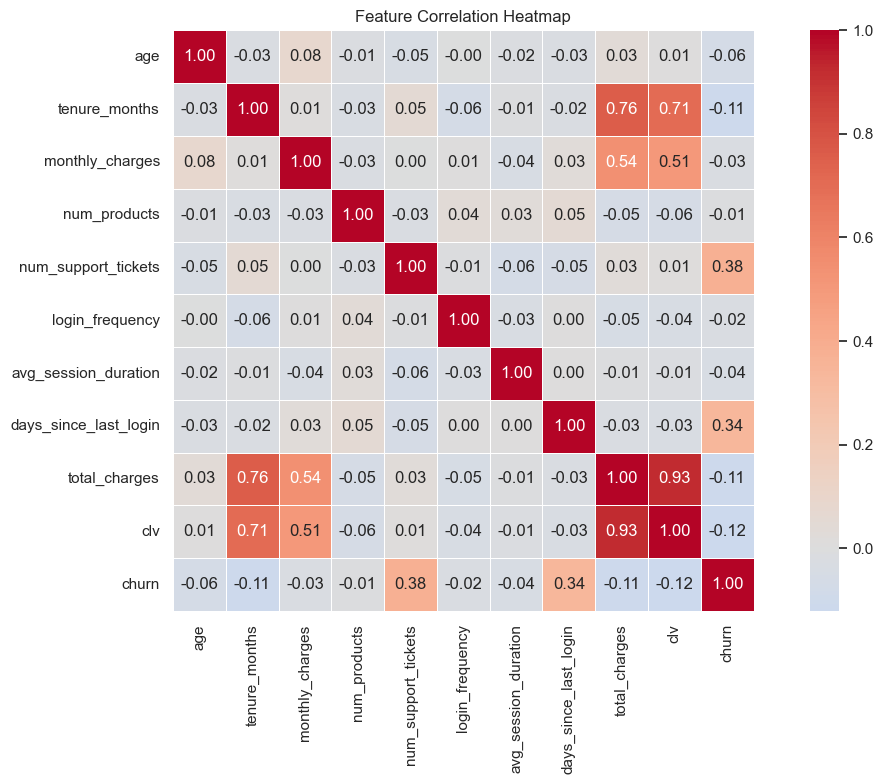

In [9]:
plt.figure(figsize=(12, 8))

num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()

sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
print("="*55)
print("🔍 KEY INSIGHTS FROM EDA")
print("="*55)

# Churn by contract
ct = df.groupby("contract_type")["churn"].mean()
print(f"\n📋 Churn Rate by Contract:")
for k, v in ct.items():
    print(f"   {k:<20}: {v*100:.1f}%")

# Avg days since login for churned vs not
avg_login = df.groupby("churn")["days_since_last_login"].mean()
print(f"\n📋 Avg Days Since Login:")
print(f"   Stayed  : {avg_login[0]:.1f} days")
print(f"   Churned : {avg_login[1]:.1f} days")

# Avg support tickets
avg_tickets = df.groupby("churn")["num_support_tickets"].mean()
print(f"\n📋 Avg Support Tickets:")
print(f"   Stayed  : {avg_tickets[0]:.1f}")
print(f"   Churned : {avg_tickets[1]:.1f}")
print("="*55)

🔍 KEY INSIGHTS FROM EDA

📋 Churn Rate by Contract:
   Month-to-Month      : 85.4%
   One Year            : 37.5%
   Two Year            : 32.7%

📋 Avg Days Since Login:
   Stayed  : 67.9 days
   Churned : 103.7 days

📋 Avg Support Tickets:
   Stayed  : 3.2
   Churned : 5.5
